In [ ]:
!pip install kaggle

In [ ]:
kaggle = '/content/kaggle.json'

In [ ]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [ ]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [ ]:
len(data_0)

2236

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
dataset_path = '/content/dataset'

X = []
y = []

for label in range(10):
    folder_path = os.path.join(dataset_path, str(label))
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)

        img = Image.open(img_path).convert('L')  # grayscale
        img = img.resize((28, 28))               # resize ke 28x28

        img_array = np.array(img)

        # invert warna
        img_array = 255 - img_array

        X.append(img_array)
        y.append(label)

X = np.array(X)
y = np.array(y)

In [ ]:
print("Jumlah data:", X.shape)
print("Jumlah label:", y.shape)

Jumlah data: (21555, 28, 28)
Jumlah label: (21555,)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

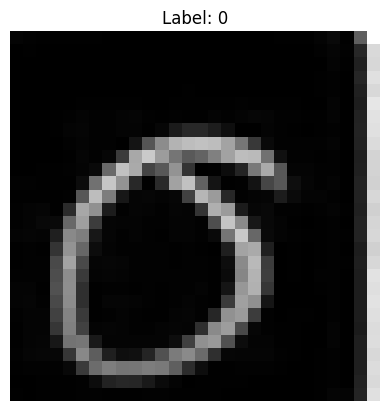

In [ ]:
plt.imshow(X[0], cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')

menunjukkan salah satu contoh citra dari dataset handwritten digits yang udah berhasil dimuat. Citra ditampilin pake mode grayscale resolusi 28×28 piksel. Label yag ada pada gambar nunjukin kelas angka, yaitu 0. Visualisasi ini punya tujuan buat mastiin kalau proses pembacaan data, pelabelan, sama konversi citra ke bentuk array numerik udah berjalan dengan benar sebelum masuk ke tahap preprocessing lanjutan dan pelatihan model.

In [ ]:
# Normalisasi pixel (0–255 =  0–1)
X = X / 255.0

# Reshape: 28x28 = 784
X = X.reshape(X.shape[0], 784)

Normalisasi membuat proses trainingnya lebih stabil

Reshape dipakai karena MLP cuman terima input 1D, bukan matriks 2D

In [ ]:
print(X.shape)

(21555, 784)


In [ ]:
# encoding label (one hot)
y_encoded = to_categorical(y, num_classes=10)

In [ ]:
print(y_encoded.shape)
print(y[:5])
print(y_encoded[:5])

(21555, 10)
[0 0 0 0 0]
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
#arsitektur model MLP
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Early stoping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
#training model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3010 - loss: 1.9981 - val_accuracy: 0.5929 - val_loss: 1.3355
Epoch 2/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5654 - loss: 1.3737 - val_accuracy: 0.6912 - val_loss: 1.0071
Epoch 3/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6616 - loss: 1.0774 - val_accuracy: 0.7483 - val_loss: 0.8365
Epoch 4/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7186 - loss: 0.8973 - val_accuracy: 0.7843 - val_loss: 0.6994
Epoch 5/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7555 - loss: 0.7723 - val_accuracy: 0.8104 - val_loss: 0.6073
Epoch 6/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7876 - loss: 0.6847 - val_accuracy: 0.8362 - val_loss: 0.5618
Epoch 7/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8105 - loss: 0.6035 - val_accuracy: 0.8376 - val_loss: 0.5205
Epoch 8/50
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8164 - loss: 0.5717 - val_accuracy: 0.

In [ ]:
#evaluasi model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8767 - loss: 0.4060
Test Accuracy: 0.8779865503311157
Test Loss: 0.3948524296283722


135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


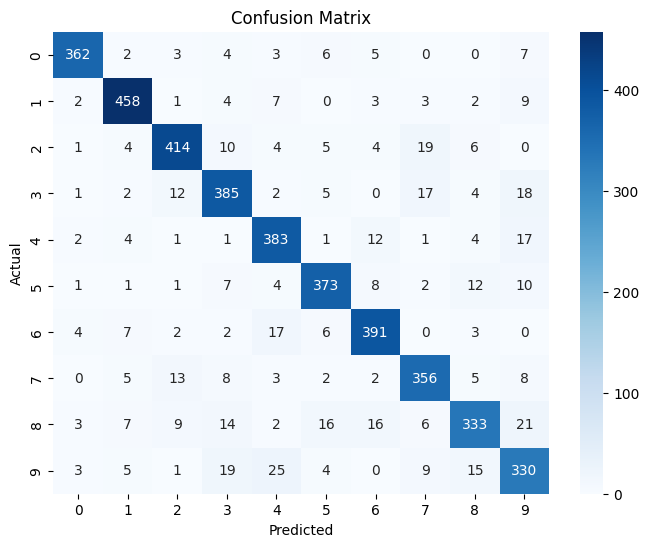

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

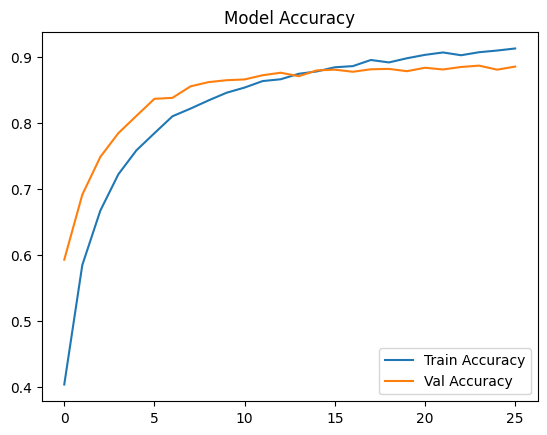

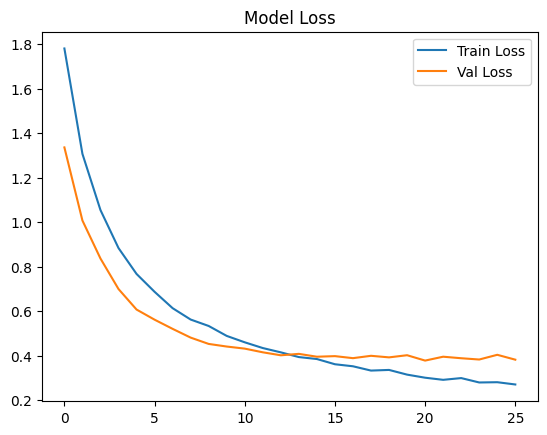

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()